# Анализ обученных моделей

Обучение и логирование результатов велось в MLFlow, здесь показаны основные результаты. 

Для использование была выбрана модель YOLO-seg от Ultralytics, в силу широкого использвоания этих моделей, а также наличия удобной инфраструктуры для обучения и логирвоания результатов.

In [1]:
import mlflow

mlflow.set_tracking_uri("mlflow_logs")
from IPython.display import Image, display

In [2]:
columns_to_show = [
    "run_id",
    "params.model",
    "params.epochs",
    "params.batch",
    "params.multi_scale",
    "params.auto_augment",
    "params.augmentations",
    "metrics.metrics/recallM",
    "metrics.metrics/precisionM",
    "metrics.metrics/mAP50M",
]

## Модель повреждений

В таблице ниже показаны результаты метрики предсказания масок повреждений для проведенных экспериментов, они отсортированы по метрике `mAP50M`. Для начала были полность выключены аугментации (`auto_augment=None`, `augmentations=[]`) и были протестированы 10 и 50 эпох. Видно, что в таком режиме модель быстро переобучается, поэтому далее были протестированы несколько режимов аугментаций: полностью дефолтные с использованием библиотеки albumentations (`auto_augment=randaugment`, `augmentations=None`), дефолтные без albumentations (`auto_augment=randaugment`, `augmentations=[]`) и наконец некоторый кастомные набор аугментаций. С использованием аугментаций качество, ожидаемо, существенно возрастает. При этом лучше всего работают дефолтные с использованием библиотеки albumentations, на них решено было остановится. Также было протестированыо обучение с автоатическим апскейлом и даунскейлом картинок к разному размеру на разных батчах (`multi_scale=0.25`), качество оказалось несколько ниже. Также была протестирована модель `yolo26n-seg` против `yolo11n-seg`, более новая модель оказалась хуже, поэтому было решено остановится на `yolo11n-seg`.

In [3]:
experiment_name = "CarDD_merged"
experiment = mlflow.get_experiment_by_name(experiment_name)
runs_df = mlflow.search_runs(experiment_ids=[experiment.experiment_id])
existing_cols = [c for c in columns_to_show if c in runs_df.columns]
summary_table = runs_df[existing_cols].sort_values(
    by="metrics.metrics/mAP50M", ascending=False
)
summary_table

,run_id,params.model,params.epochs,params.batch,params.multi_scale,params.auto_augment,params.augmentations,metrics.metrics/recallM,metrics.metrics/precisionM,metrics.metrics/mAP50M
2,4cd8b6971f5d4e2fbd39d3a0a491891f,yolo11n-seg.pt,50,16,0.0,randaugment,None,0.671345,0.772535,0.726683
4,e6a18f323cb64e179cd36970fed431b6,yolo11n-seg.pt,50,16,0.0,randaugment,[],0.695322,0.748090,0.718789
1,28314c6c5c664e28aef1865ab133c151,yolo11n-seg.pt,50,16,0.25,randaugment,None,0.688667,0.736727,0.713158
3,60b3cfb7d28c40a6adacacfbb8665da8,yolo11n-seg.pt,50,16,0.0,randaugment,"[[RandomShadow(p=0.4, num_shadows_limit=(1, 3)...",0.699639,0.735796,0.710147
0,05077f1a46924030a659c4d65b029138,yolo26n-seg.pt,50,16,0.25,randaugment,None,0.679257,0.730742,0.706381
5,7be045f11529427595ec6e8eecfba6cd,yolo11n-seg.pt,10,16,0.0,None,[],0.584688,0.666084,0.610783
6,dbdab50ef9ed421fa512e7312774b06e,yolo11n-seg.pt,50,16,0.0,None,[],0.562309,0.689995,0.569169


In [4]:
labels_image_path = "mlflow_logs/746981271456925267/4cd8b6971f5d4e2fbd39d3a0a491891f/artifacts/val_batch2_labels.jpg"
preds_image_path = "mlflow_logs/746981271456925267/4cd8b6971f5d4e2fbd39d3a0a491891f/artifacts/val_batch2_pred.jpg"

Ниже показаны примеры предсказаний лучшей обученной модели на валидационной части датасета. Видно, что они в целом соответсвуют лейблам, однако наблюдается недопредсказанность отдельных повреждений или их участков и иногда детектирование ложных повреждений за пределами автомобиля (верхняя правая картинка).

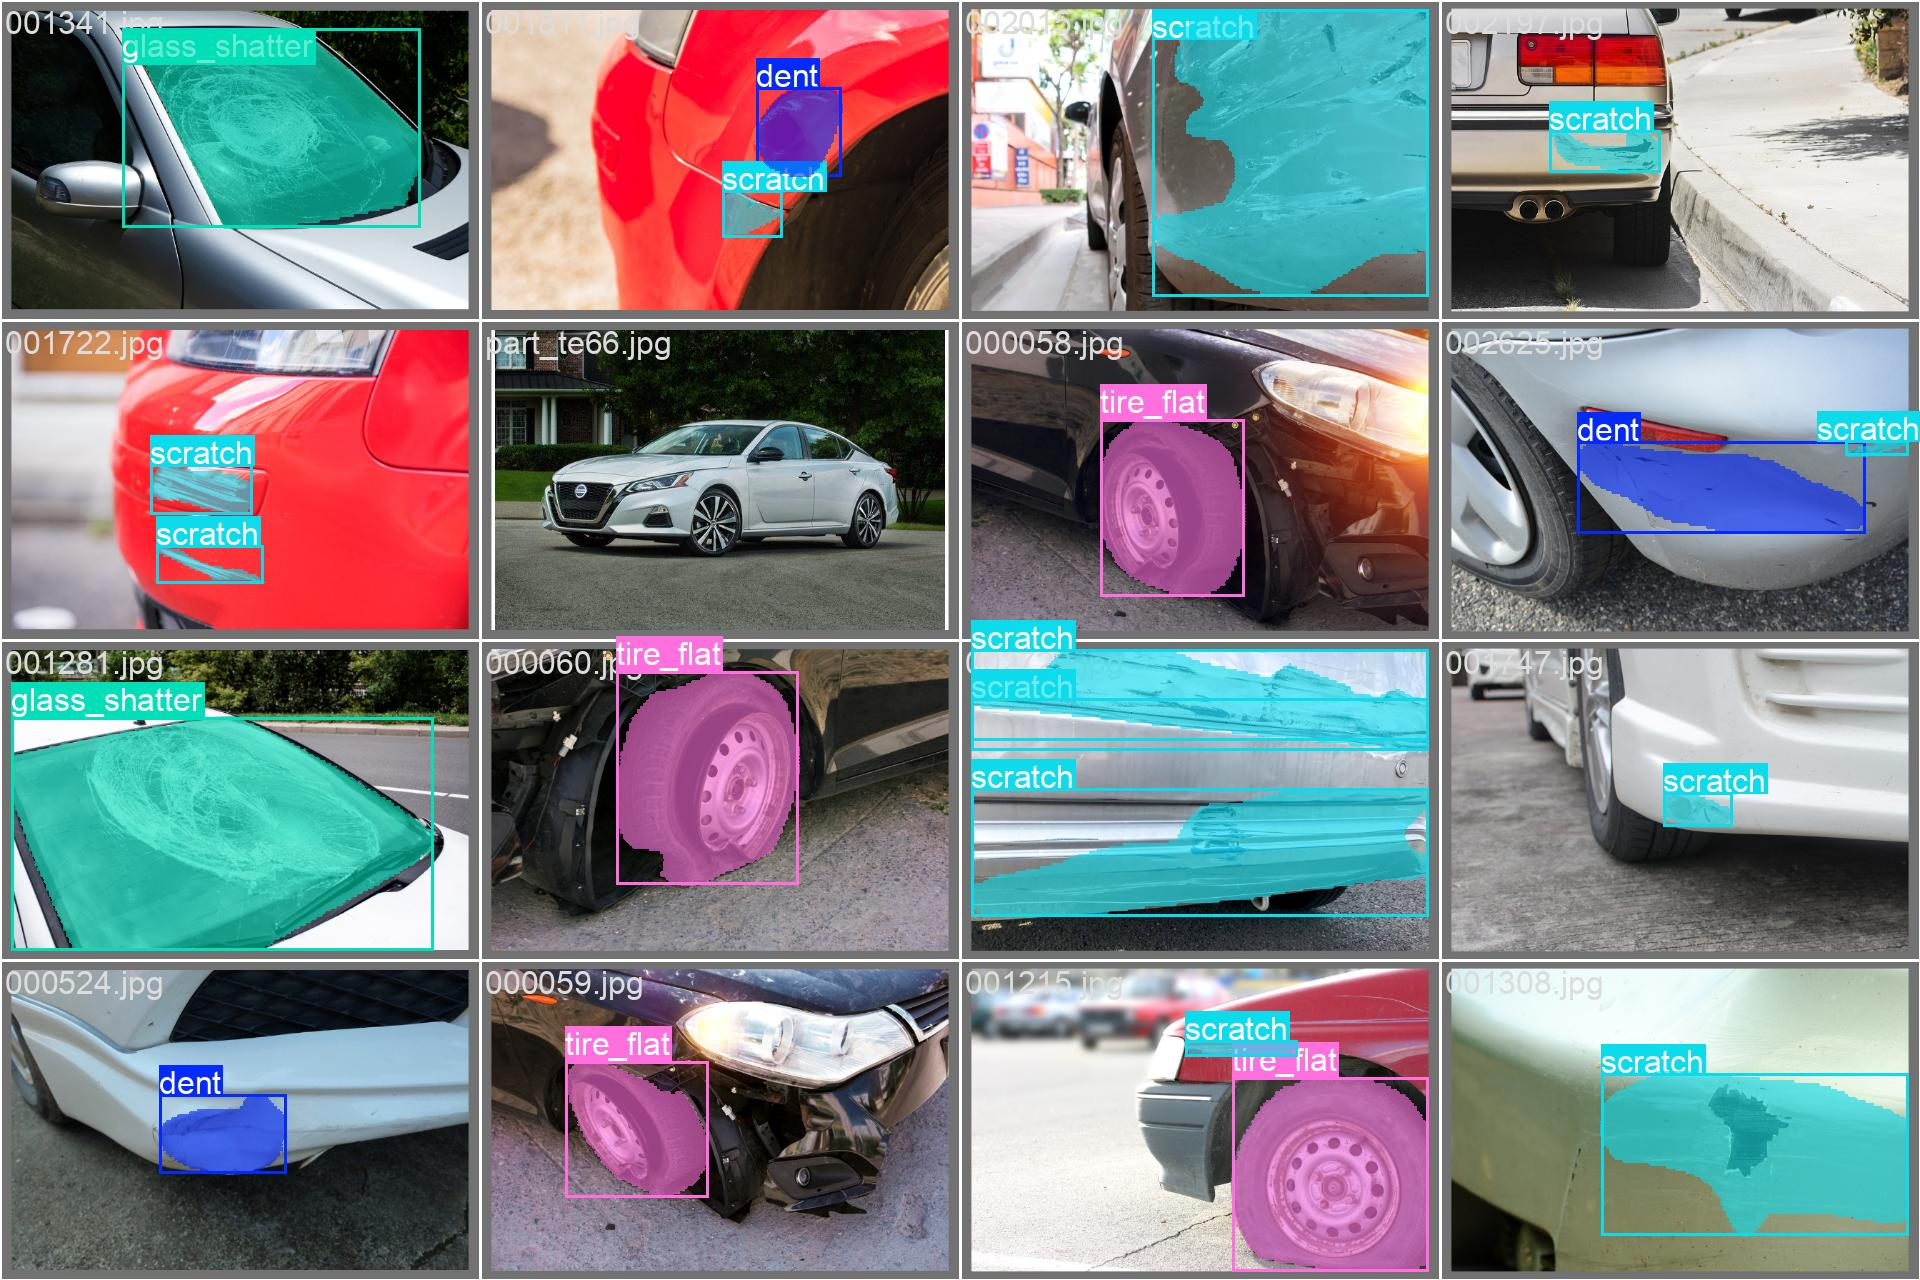

In [ ]:
display(Image(filename=labels_image_path, width=800))  # лейблы

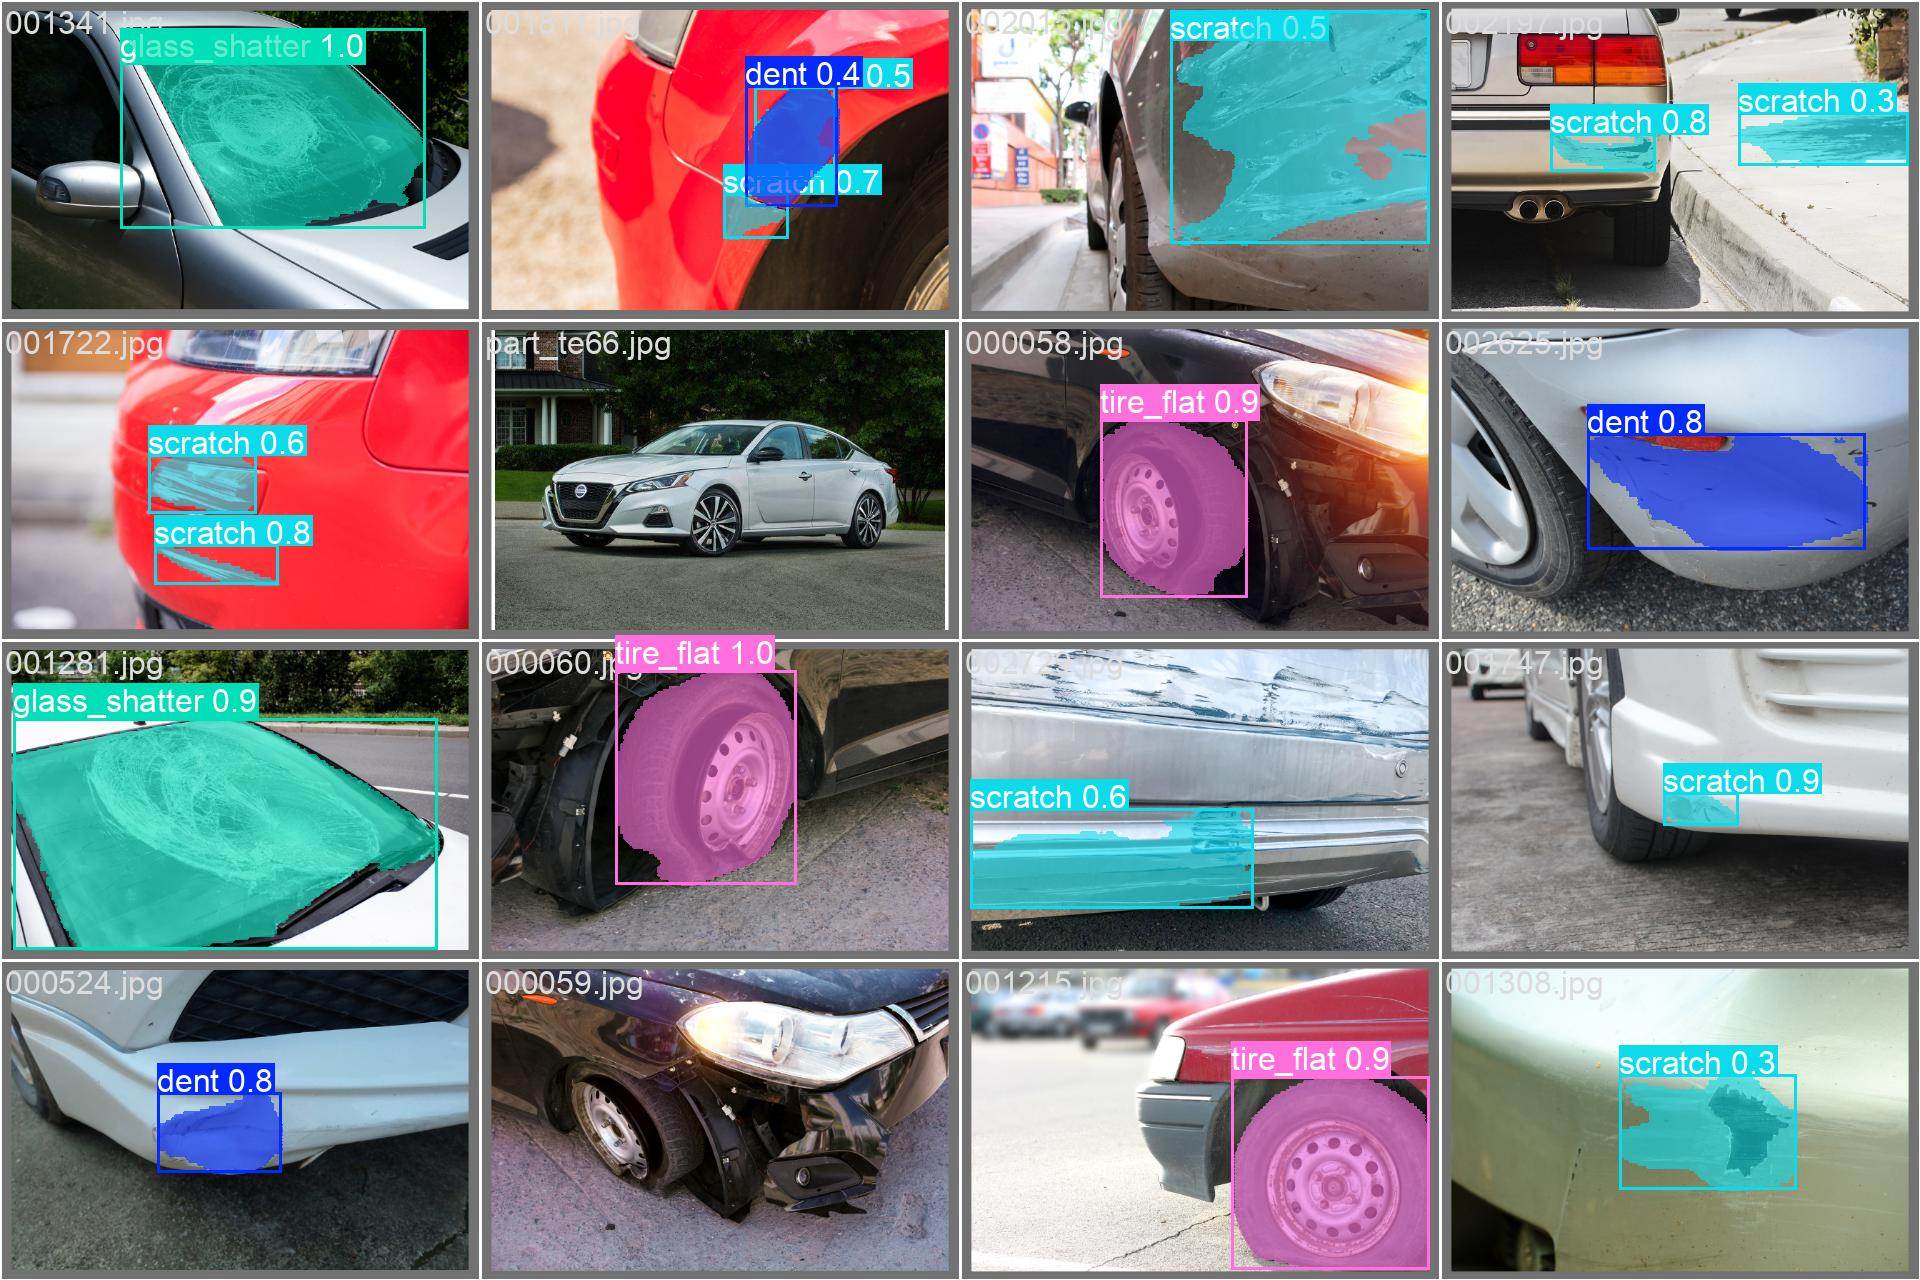

In [ ]:
display(Image(filename=preds_image_path, width=800))  # предсказания

## Модель деталей

В таблице ниже показаны результаты метрики предсказания масок деталей для проведенных экспериментов, они отсортированы по метрике `mAP50M`. Качество в среднем выше, чем для задачи поиска повреждений. Был проведен примерно такой же набор экспериментов, что и для модели повреждений, результаты в целом согласуются. Был выбран меньший размер батча в силу меньшего размера датасета. Основной вывод аугментации очень важны для итогового качества модели, в данном случае параметр `multi_scale=0.25` дает некоторый прирост качества, по сравнению с его отсутсвием. Дополнительно была протестирована модель `yolo11s-seg` против `yolo11n-seg`, модель `s` большего размера показала несколько лучщая качество, однако для повышения скорости инференса, решено далее использовать модель `n`, так как разрав в качестве небольшой.

In [7]:
experiment_name = "Carparts"
experiment = mlflow.get_experiment_by_name(experiment_name)
runs_df = mlflow.search_runs(experiment_ids=[experiment.experiment_id])
existing_cols = [c for c in columns_to_show if c in runs_df.columns]
summary_table = runs_df[existing_cols].sort_values(
    by="metrics.metrics/mAP50M", ascending=False
)
summary_table

,run_id,params.model,params.epochs,params.batch,params.multi_scale,params.auto_augment,params.augmentations,metrics.metrics/recallM,metrics.metrics/precisionM,metrics.metrics/mAP50M
1,5f4f4f53ce7f4dd0bca61ac73ab99190,yolo11s-seg.pt,50,8,0.25,randaugment,None,0.863236,0.923756,0.937734
2,d6efbba2cbf441248186af02f4f08ca8,yolo11n-seg.pt,50,8,0.25,randaugment,None,0.878762,0.926834,0.921054
3,944c2add9aef4316b2b0b43c7771cffb,yolo11n-seg.pt,50,8,0.0,randaugment,None,0.861837,0.901486,0.917341
4,9c3277a37a0540929d027b1aad29e101,yolo11n-seg.pt,50,8,0.0,randaugment,[],0.836443,0.910545,0.910487
5,52996ca9460e4113ba7e24d424a6d769,yolo11n-seg.pt,50,8,0.0,None,[],0.760917,0.865529,0.840968
0,47d7801a93df42278177938e2b040b34,yolo26n-seg.pt,50,8,0.25,randaugment,None,0.721302,0.784795,0.814741
6,69c9d5a6721b451eb7b07051f8fa264a,yolo11n-seg.pt,10,8,0.0,None,[],0.710006,0.777740,0.766950


In [8]:
labels_image_path = "mlflow_logs/280109531373852209/47d7801a93df42278177938e2b040b34/artifacts/val_batch0_labels.jpg"
preds_image_path = "mlflow_logs/280109531373852209/47d7801a93df42278177938e2b040b34/artifacts/val_batch0_pred.jpg"

Ниже показаны примеры предсказаний лучшей обученной модели на валидационной части датасета. Видно, что они в целом соответсвуют лейблам, однако наблюдается недопредсказанность отдельных деталей на изображениях под углом. В остальном же качество визкально существенно выше, чем для задачи поиска повреждений.

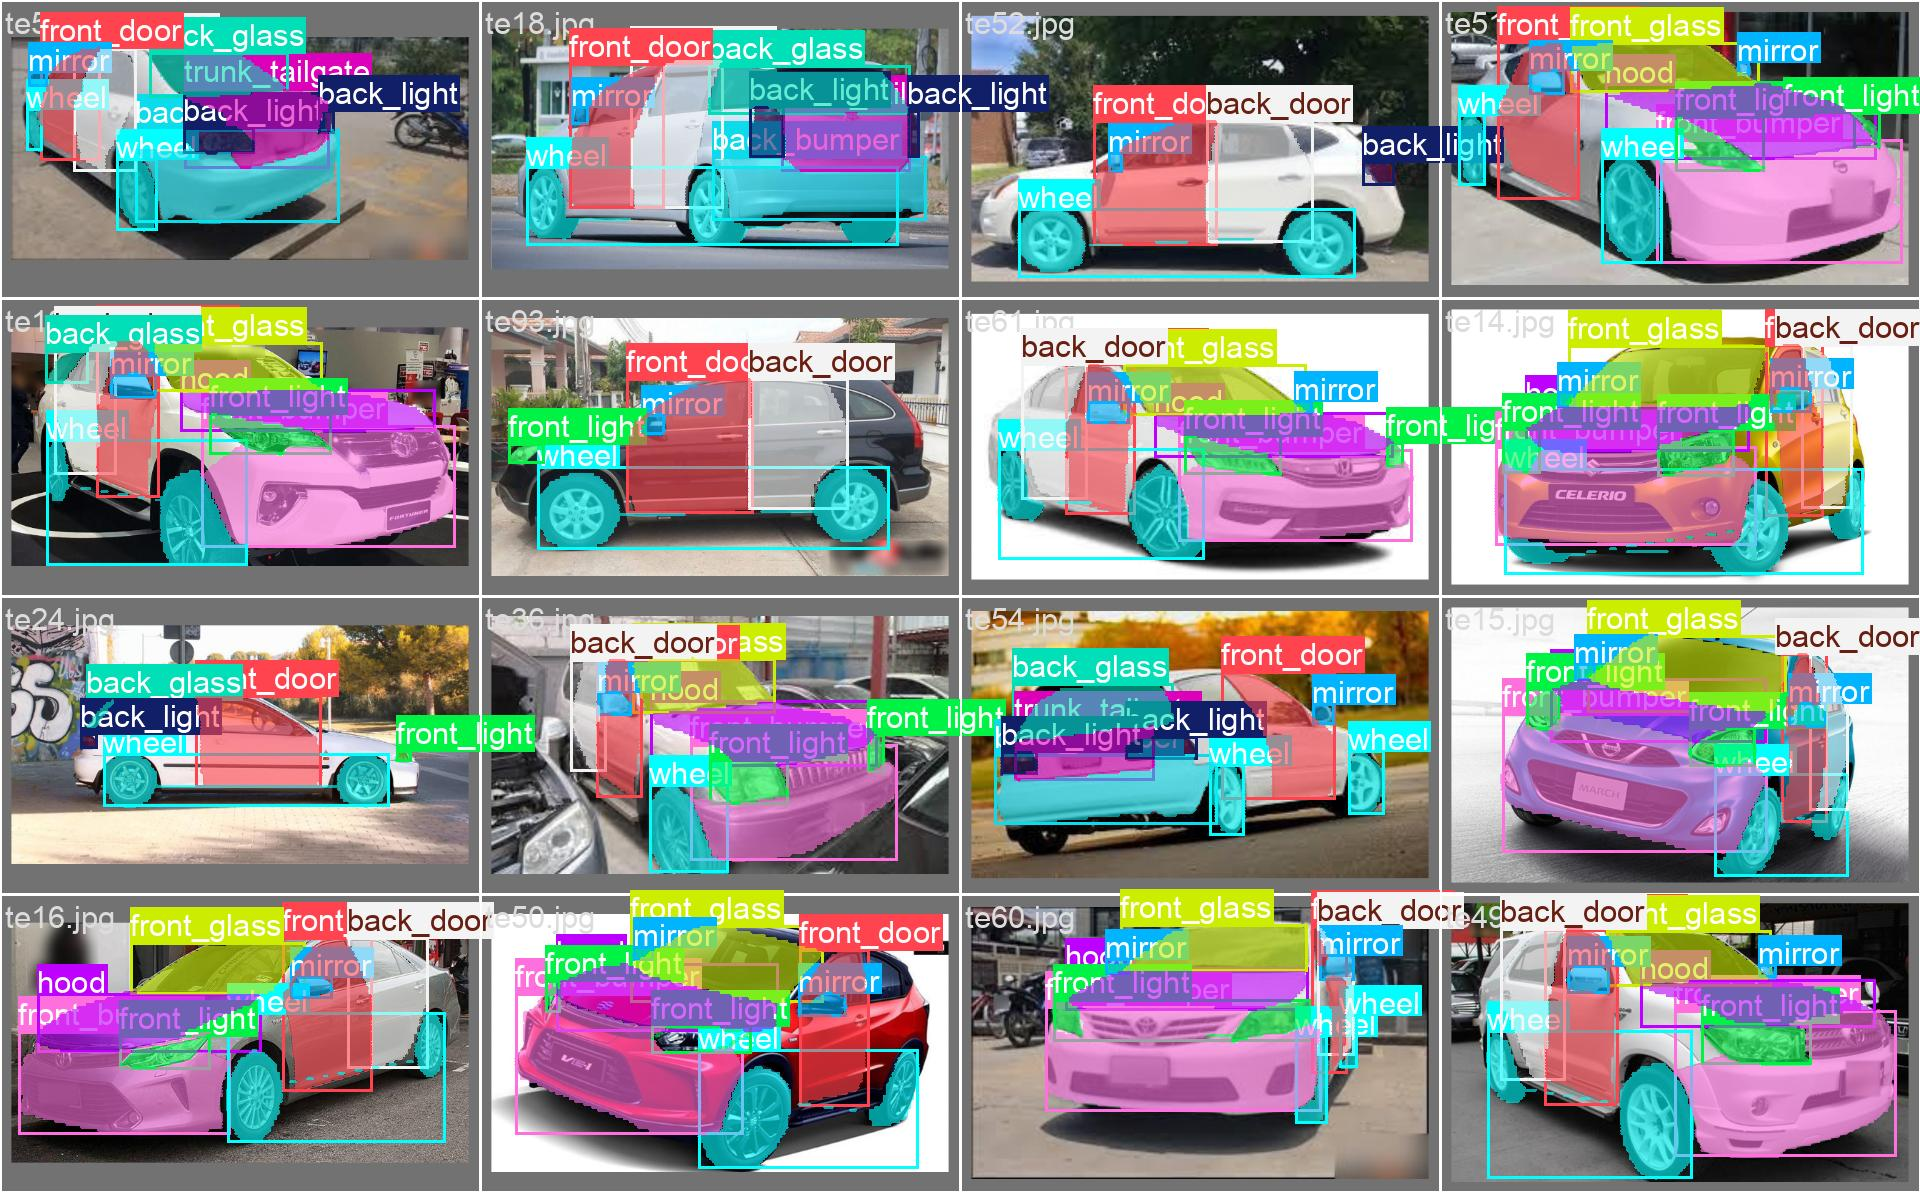

In [ ]:
display(Image(filename=labels_image_path, width=800))  # лейблы

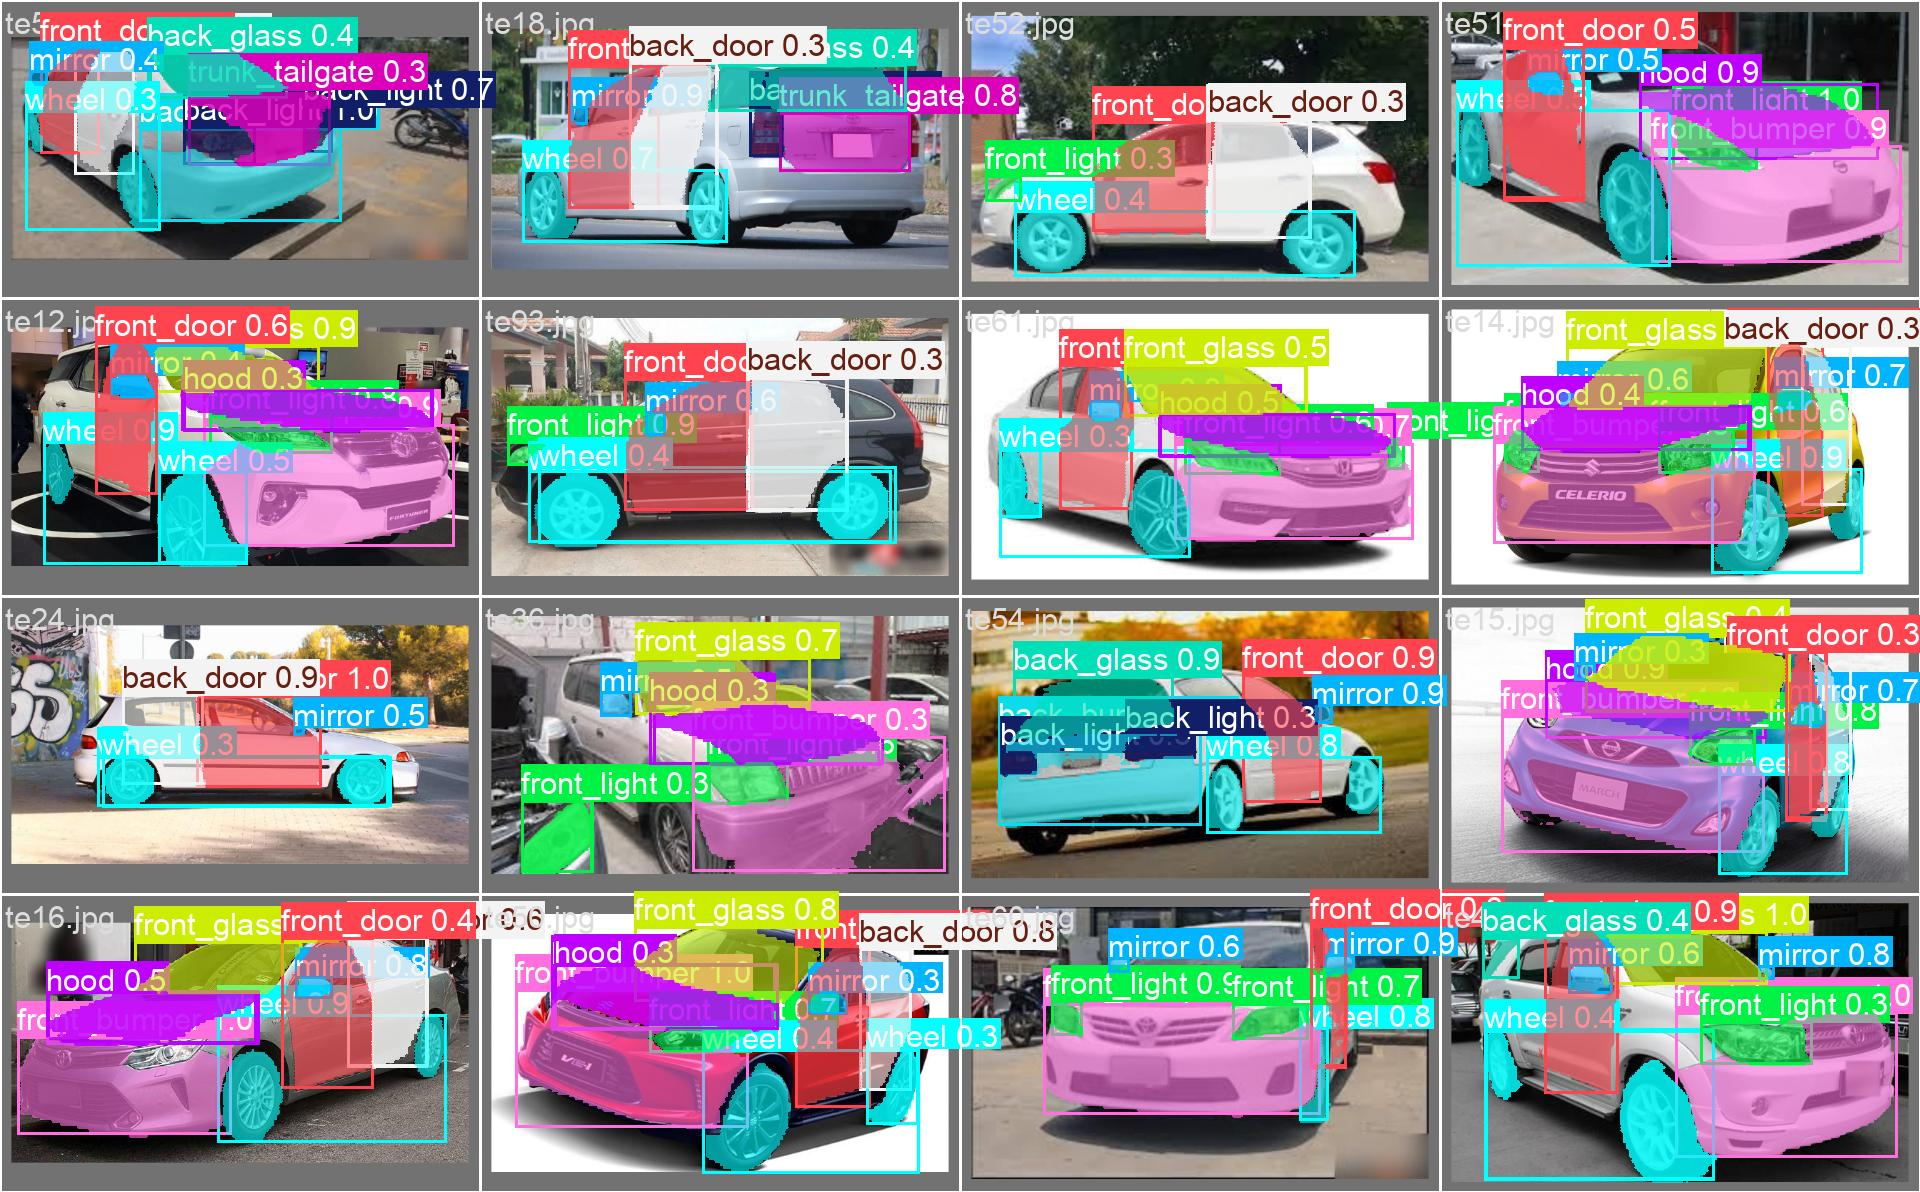

In [ ]:
display(Image(filename=preds_image_path, width=800))  # предсказания